# La santé mentale après la Première Guerre mondiale

#  Extraction de Keywords pour la période 1919-1929

## Imports

In [1]:
import os
import yake

## Extraire les mots clés d'un document avec Yake

In [2]:
# Instantier l'extracteur de mots clés
kw_extractor = yake.KeywordExtractor(lan="fr", top=50)
kw_extractor

In [3]:
# Lister les Fichiers
txt_path = '../../data/camille_folie_AND_guerre'
txts = [f for f in os.listdir(txt_path) if os.path.isfile(os.path.join(txt_path, f)) and f.endswith(".txt")]

# Imprimer le nombre de fichiers identifiés
len(txts)

735

## Extraction des mots clefs 

In [8]:
for f in sorted(txts):
    text = open(os.path.join(txt_path, f), 'r', encoding="utf-8").read()
    keywords = kw_extractor.extract_keywords(text)
    kept = []
    for kw, score in keywords:
        words = kw.split()
        if len(words) == 2:
            kept.append(kw)
    print(f"{f} mentions these keywords: {', '.join(kept)}...")

KB_JB567_1919-01-09_01-00002.txt mentions these keywords: L'officier auxiliaire, français blessé, blessés français, officier français, prisonniers Français, soldats d'infanterie, lre classe, soldats français, los Allemands, auxiliaire d'infanterie, blessés allemands, soldats allemands...
KB_JB567_1919-01-20_01-00002.txt mentions these keywords: d'infanterie Van, soldats d'infanterie, décoration militaire, Nouvelles L'association, L'association catholique, Van Camp, soldat d'artillerie, sergent d'infanterie, gouvernement allemand...
KB_JB567_1919-01-24_01-00001.txt mentions these keywords: minnVo VENDREDI, parti ouvrier, conférence internationale, socialistes allemands, capitaines commandants...
KB_JB567_1919-02-23_01-00002.txt mentions these keywords: van Vollenhoven, Casson aurait, Libre Belgique, dépenses extraordinaires, sûreté militaire, haut d'une, d'une échelle, grand nombre...
KB_JB567_1919-02-27_01-00001.txt mentions these keywords: directeur général, syndicat national, secréta

# Analyse des fréquences lexicales

## Imports et dépendances

In [4]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elhaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Créer une liste de stopwords

In [31]:
# Stopwords
sw = stopwords.words("french")
sw += ["les", "bon", "rue", "faire", "tout", "plus", "ruo", "dem", "bruxelles", "adr", "avenue", "place", "cette",
       "ans", "demande", "rossel", "ecr", "sans", "fait", "bien", "comme", "art", "tous", "être", "dont", "toutes",
         "avant", "dont", "leurs", "van", "très", "bons", "dés", "deux", "etc", "celle", "après", "serv", "entre", 
         "bel", "vendre", "vend", "maison", "prix", "sous", "quo", "fille", "brux", "réf", "ceux", "encore", "toutes", "autres",
         "agence", "heures", "eor", "part", "bonne", "prés", "faut", "avoir", "pendant", "pers", "doit", "aussi", "toute", "suite", 
         "ainsi", "ici", "dos", "midi", "louer", "grand", "référ", "pet", "jour", "jours", "cour", "matin", "uno", "lieu", "chez", "mois",
         "dit", "dès", "sach", "demi", "toujours", "non", "déjà", "voir", "app", "vient", "fem", "celui", "fil", "mat", "los", "dom", 
         "cet", "elles", "petit", "devant", "dcm", "présent", "sér", "nom", "com", "hom", "vue", "quelques", "moins", "peut", "peu", 
         "vers", "depuis", "dire", "car", "hier", "soir", "jeudi", "vendredi", "samedi", "lundi", "mardi", "faire", "dit", "demandes", 
         "écrit", "depuis", "dont", "tant", "près", "jamais", "fois", "neuf", "quatre", "gros", "premier",
         "gens", "cas", "moment", "question"]
sw = set(sw)

In [32]:
print(f"{len(sw)} stopwords:\n {sorted(sw)}")

293 stopwords:
 ['adr', 'agence', 'ai', 'aie', 'aient', 'aies', 'ainsi', 'ait', 'ans', 'app', 'après', 'art', 'as', 'au', 'aura', 'aurai', 'auraient', 'aurais', 'aurait', 'auras', 'aurez', 'auriez', 'aurions', 'aurons', 'auront', 'aussi', 'autres', 'aux', 'avaient', 'avais', 'avait', 'avant', 'avec', 'avenue', 'avez', 'aviez', 'avions', 'avoir', 'avons', 'ayant', 'ayante', 'ayantes', 'ayants', 'ayez', 'ayons', 'bel', 'bien', 'bon', 'bonne', 'bons', 'brux', 'bruxelles', 'c', 'car', 'cas', 'ce', 'celle', 'celui', 'ces', 'cet', 'cette', 'ceux', 'chez', 'com', 'comme', 'cour', 'd', 'dans', 'dcm', 'de', 'dem', 'demande', 'demandes', 'demi', 'depuis', 'des', 'deux', 'devant', 'dire', 'dit', 'doit', 'dom', 'dont', 'dos', 'du', 'dès', 'déjà', 'dés', 'ecr', 'elle', 'elles', 'en', 'encore', 'entre', 'eor', 'es', 'est', 'et', 'etc', 'eu', 'eue', 'eues', 'eurent', 'eus', 'eusse', 'eussent', 'eusses', 'eussiez', 'eussions', 'eut', 'eux', 'eûmes', 'eût', 'eûtes', 'faire', 'fait', 'faut', 'fem', 'fil

In [33]:
# Stocker le contenu des fichiers dans une liste
content_list = []
for txt in txts:
    with open(os.path.join(txt_path, txt), 'r', encoding='utf-8') as f:
        content_list.append(f.read())

In [34]:
# Compter le nombre d'éléments (=fichiers) dans la liste
len(content_list)

735

In [35]:
# Ecrire tout le contenu dans un fichier temporaire
temp_path = '../../data/tmpo'
if not os.path.exists(temp_path):
    os.mkdir(temp_path)
with open(os.path.join(temp_path, "corpus_folie_guerre.txt"), "w", encoding="utf-8") as f:
    f.write(" ".join(content_list))

In [36]:
# Imprimer le contenu du fichier et constater les "déchets"
with open(os.path.join(temp_path, "corpus_folie_guerre.txt"), 'r', encoding='utf-8') as f:
    before = f.read()

before[:500]

'990! 4e vie chère votée dans le dernier Conseil des \' ministres. Les assistants, au nombre de ■150 environ, après avoir pris connaissance "bs nouvelles propositions qui leur étaient dtes par le gouvernement, ont décidé d\'en- oyer une délégation auprès du chef de canet pour faire valoir leurs revendications. inr tous res fouetioniiaires è l\'Etat UNE IMPORTANTE DÉCISION A la suite d\'uae nouvelle entrevue qu\'il I aae mercredi à midi avec les postiers, M. Léon Delacroix a décidé d\'accorder à as les '

## Nettoyer le fichier à l'aide d'une fonction de nettoyage

In [37]:
def clean_text_corpus(input_filename, folder):
    input_path = os.path.join(folder, input_filename)
    output_path = os.path.join(folder, input_filename.replace(".txt", "_clean.txt"))

    output = open(output_path, "w", encoding="utf-8")

    with open(input_path, 'r', encoding='utf-8') as f:
        text = f.read()
        words = nltk.wordpunct_tokenize(text)
        kept = [
            w.upper() for w in words
            if len(w) > 2 and w.isalpha() and w.lower() not in sw
        ]
        kept_string = " ".join(kept)
        output.write(kept_string)

    output.close()
    return f"Output has been written in {output_path}!"

### Appliquer la fonction sur le fichier complet 

In [38]:
clean_text_corpus("corpus_folie_guerre.txt", folder=temp_path)

'Output has been written in ../../data/tmpo\\corpus_folie_guerre_clean.txt!'

In [39]:
# Vérifier le résultat
with open(os.path.join(temp_path, "corpus_folie_guerre_clean.txt"), 'r', encoding='utf-8') as f:
    after = f.read()

after[:500]

'VIE CHÈRE VOTÉE DERNIER CONSEIL MINISTRES ASSISTANTS NOMBRE ENVIRON PRIS CONNAISSANCE NOUVELLES PROPOSITIONS DTES GOUVERNEMENT DÉCIDÉ OYER DÉLÉGATION AUPRÈS CHEF CANET VALOIR REVENDICATIONS INR RES FOUETIONIIAIRES ETAT IMPORTANTE DÉCISION UAE NOUVELLE ENTREVUE AAE MERCREDI POSTIERS LÉON DELACROIX DÉCIDÉ ACCORDER FONCTIONNAIRES AGENTS ETAT ANE INDEMNITÉ VIE CHÈRE SIX FRANCS AUGMENTÉE ALLOCATION FRANC FEMME ENFANT POSTIERS DÉCLARÉ REPRENDRAIENT TRAVAIL COMMENT ALLEMANDS FAISAIENT GUERRE ASSASSINAT'

### Afficher les termes les plus fréquents


In [84]:
frequencies = Counter(after.split())
print(frequencies.most_common(10))

[('GUERRE', 3821), ('GOUVERNEMENT', 3809), ('FRANCS', 3508), ('BELGIQUE', 3431), ('CONTRE', 3361), ('PAYS', 3064), ('FRANCE', 2987), ('PARIS', 2972), ('BELGE', 2961), ('ANVERS', 2817)]


# Nuages de mots

In [28]:
from collections import Counter
from wordcloud import WordCloud
import os
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from IPython.display import Image

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elhaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Créer, stocker et afficher le nuage de mots

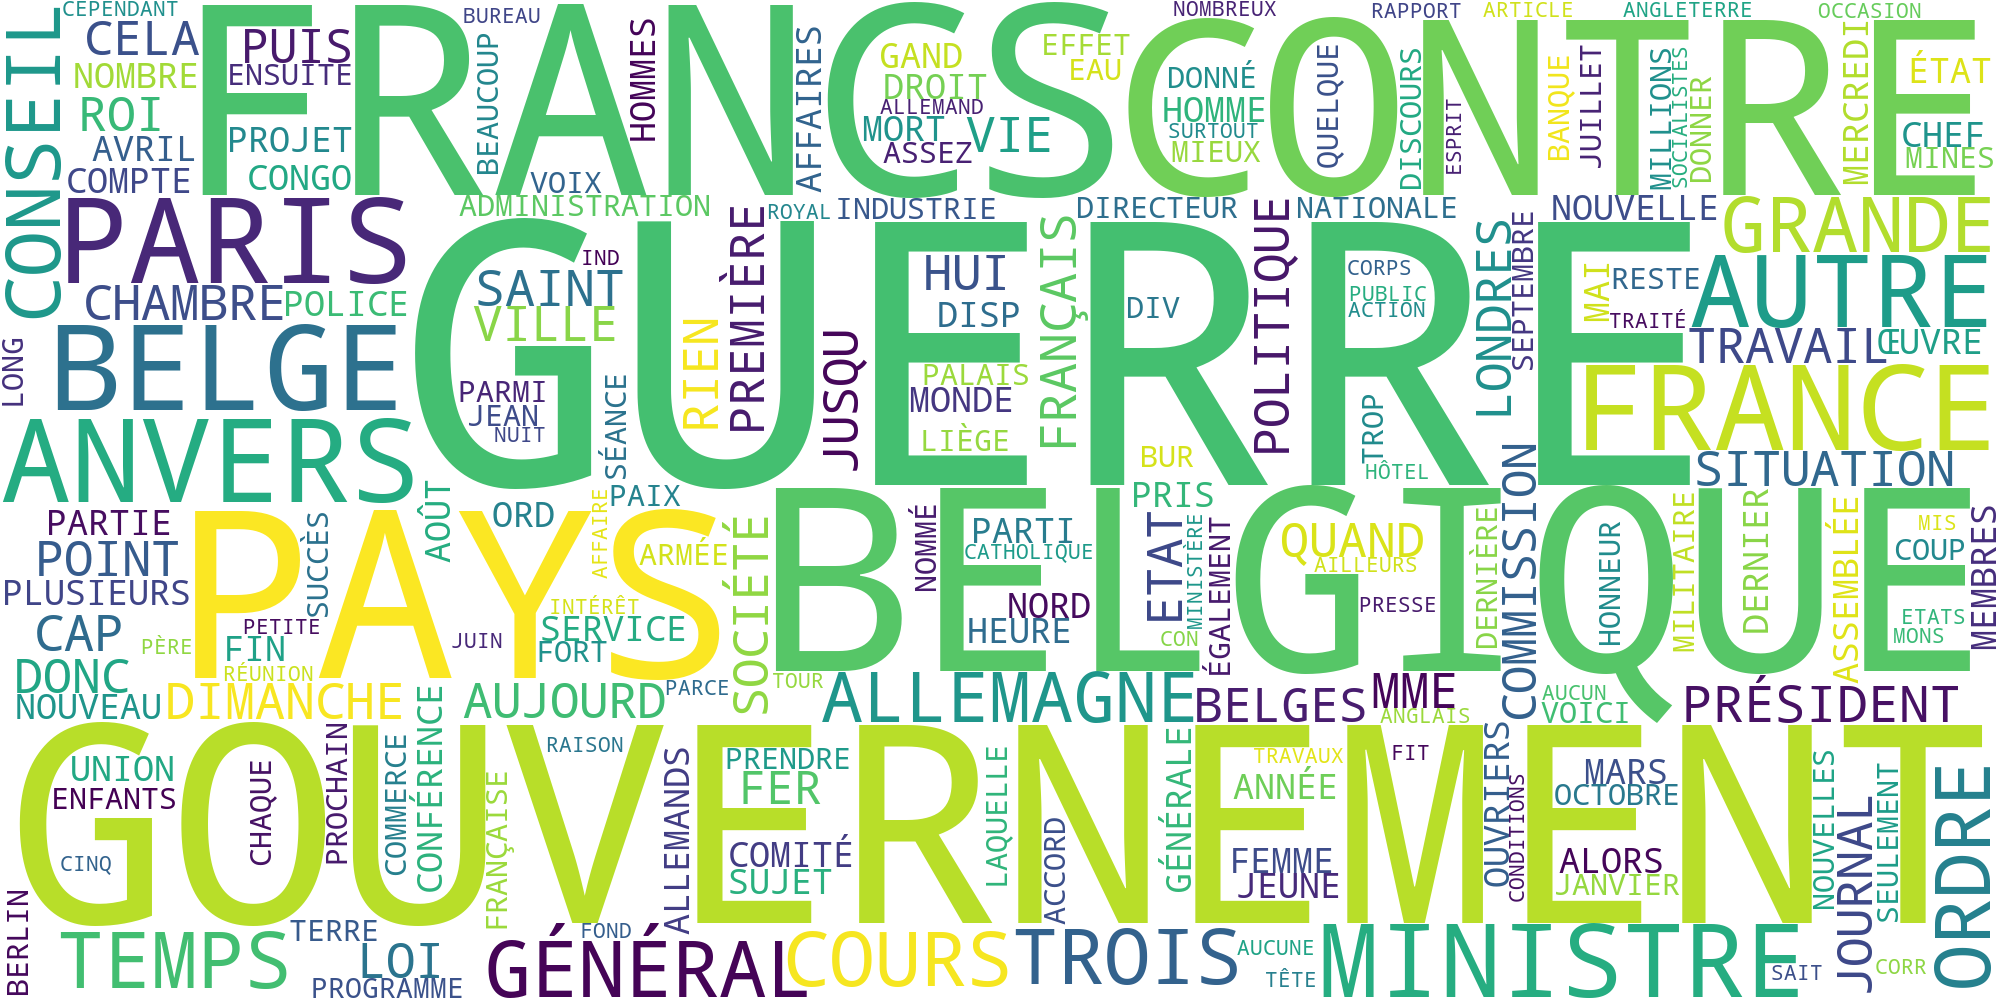

In [44]:
cloud = WordCloud(width=2000, height=1000, background_color='white').generate_from_frequencies(frequencies)
cloud_path = os.path.join(temp_path, "wordcloud_folie_guerre.png")
cloud.to_file(cloud_path)
Image(filename=cloud_path)

# Word Embeddings : le modèle Word2Vec

In [46]:
import sys

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

import nltk
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode

## Crée un fichier ou les phrases sont ségmentés

In [47]:
import os
import re

# Mon dossier de textes
txt_path = "../../data/camille_folie_AND_guerre"

# Où écrire le fichier de phrases
out_sents = "../../data/sents_folie_guerre.txt"

# Regex simple pour couper en phrases
sent_split = re.compile(r'(?<=[\.\?\!])\s+')

n_sents = 0
with open(out_sents, "w", encoding="utf-8") as out:
    for f in sorted(os.listdir(txt_path)):
        if not f.endswith(".txt"):
            continue
        with open(os.path.join(txt_path, f), "r", encoding="utf-8", errors="ignore") as inp:
            text = inp.read().replace("\n", " ")
            sents = sent_split.split(text)
            for s in sents:
                s = s.strip()
                # garder des phrases pas trop courtes
                if len(s) >= 20:
                    out.write(s + "\n")
                    n_sents += 1

print("Fichier créé :", out_sents)
print("Nombre de phrases :", n_sents)

Fichier créé : ../../data/sents_folie_guerre.txt
Nombre de phrases : 268470


## Chargement et traitement des phrases du corpus

### Création d'un objet qui *streame* les lignes d'un fichier pour économiser de la RAM

In [ ]:
class MySentences(object):
    """Tokenize and Lemmatize sentences"""
    def __init__(self, filename):
        self.filename = filename

    def __iter__(self):
        for line in open(self.filename, encoding='utf-8', errors="backslashreplace"):
            yield [unidecode(w.lower()) for w in wordpunct_tokenize(line)]

In [53]:
infile = f"../../data/sents_folie_guerre.txt"
sentences = MySentences(infile)

### Détection des bigrams

In [54]:
bigram_phrases = Phrases(sentences)

In [55]:
type(bigram_phrases.vocab)

dict

In [56]:
len(bigram_phrases.vocab.keys())

1908845

### Conversion des `Phrases` en objet `Phraser`

In [57]:
bigram_phraser = Phraser(phrases_model=bigram_phrases)

### Extraction des trigrams

Nous répétons l'opération en envoyant cette fois la liste de bigrams afin d'extraire les trigrams.

In [58]:
trigram_phrases = Phrases(bigram_phraser[sentences])

In [59]:
trigram_phraser = Phraser(phrases_model=trigram_phrases)

### Création d'un corpus d'unigrams, bigrams, trigrams

In [60]:
corpus = list(trigram_phraser[bigram_phraser[sentences]])

## Entrainement des modèle Word2Vec sur ce corpus

In [61]:
%%time
model = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=5, # La taille du "contexte", ici 5 mots avant et après le mot observé
    min_count=5, # On ignore les mots qui n'apparaissent pas au moins 5 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

CPU times: total: 41.1 s
Wall time: 14.9 s


### Sauver le modèle dans un fichier

In [63]:
outfile = f"../../data/MProjet.model"
model.save(outfile)

## Explorer le modèle

### Charger le modèle  en mémoire

In [64]:
model = Word2Vec.load("../../data/MProjet.model")

### Calculer la similarité entre deux termes

In [69]:
model.wv.similarity("folie", "guerre")

0.3577808

In [70]:
model.wv.similarity("folie", "soldat")

0.40826654

In [ ]:
model.wv.similarity("folie", "hopital")

0.24417263

In [79]:
model.wv.similarity("folie", "francs")

0.08637744

### Chercher les mots les plus proches d'un terme donné

In [82]:
model.wv.most_similar("folie", topn=20)

[('force', 0.8873550295829773),
 ('chose', 0.8742434978485107),
 ('joie', 0.8630269765853882),
 ('maniere', 0.8401620388031006),
 ('douleur', 0.8371717929840088),
 ('pensee', 0.8294315934181213),
 ('jeune_fille', 0.8281200528144836),
 ('maladie', 0.827642023563385),
 ('passion', 0.8259097933769226),
 ('volonte', 0.8222329020500183),
 ('femme', 0.8173631429672241),
 ('beaute', 0.8131299018859863),
 ('figure', 0.8124333024024963),
 ('foi', 0.8079086542129517),
 ('preuve', 0.806124746799469),
 ('pauvre', 0.8022849559783936),
 ('sagesse', 0.7987253665924072),
 ('verite', 0.795244574546814),
 ('gloire', 0.794366180896759),
 ('tache', 0.7936679720878601)]

In [83]:
model.wv.most_similar("guerre", topn=20)

[('france', 0.7600877285003662),
 ('russie', 0.7293136715888977),
 ('belgique', 0.7136685848236084),
 ('occupation', 0.7119304537773132),
 ('grande_-_bretagne', 0.6996800303459167),
 ('paix', 0.6872320771217346),
 ('turquie', 0.6827707290649414),
 ('periode', 0.6546410322189331),
 ('mission', 0.654236376285553),
 ('bataille', 0.6525347828865051),
 ('paix_sociale', 0.6525031328201294),
 ('la_france', 0.6471273899078369),
 ('la_patrie', 0.6468209624290466),
 ('etat', 0.6408458948135376),
 ('retraite', 0.6392179131507874),
 ('periode_electorale', 0.6381050944328308),
 ('change', 0.6374925971031189),
 ('pays', 0.631453812122345),
 ('liberte', 0.6294945478439331),
 ('grande_guerre', 0.6283137798309326)]

In [99]:
model.wv.most_similar("fou", topn=20)

[('silence', 0.9004999399185181),
 ('court', 0.897773802280426),
 ('bref', 0.8969025015830994),
 ('jeune_homme', 0.8867406845092773),
 ('vide', 0.8853399753570557),
 ('reve', 0.8730978965759277),
 ('malade', 0.866878867149353),
 ('prisonnier', 0.8648101091384888),
 ('soudain', 0.86031174659729),
 ('pretre', 0.8504804968833923),
 ('mari', 0.8504682183265686),
 ('devenu', 0.8500428795814514),
 ('bon_estomac', 0.8496742248535156),
 ('personnage', 0.849211573600769),
 ('distingue', 0.8488808870315552),
 ('profond', 0.8466171622276306),
 ('poete', 0.846278190612793),
 ('poison', 0.8461915254592896),
 ('inconnu', 0.8459187150001526),
 ('charmant', 0.8454943895339966)]

In [102]:
model.wv.most_similar("soldat", topn=20)

[('duc', 0.9004808068275452),
 ('medecin', 0.8753537535667419),
 ('proprietaire', 0.8677660226821899),
 ('capitaine', 0.8657702803611755),
 ('quartier', 0.8543450832366943),
 ('comte', 0.8500123023986816),
 ('marechal', 0.8448055386543274),
 ('mari', 0.8441941142082214),
 ('docteur', 0.8392596244812012),
 ('portrait', 0.8392412662506104),
 ('piano', 0.8363425135612488),
 ('cure', 0.8357486128807068),
 ('brigadier', 0.8354278206825256),
 ('roi', 0.8326290249824524),
 ('maire', 0.8322765827178955),
 ('cultivateur', 0.8320877552032471),
 ('laboureur', 0.8303983807563782),
 ('chauffeur', 0.8298434019088745),
 ('sculpteur', 0.8288381695747375),
 ('vainqueur', 0.8288375735282898)]